In [1]:
# If needed: %pip install jdatetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jdatetime

In [2]:
data_set = pd.read_csv("../data/Divar.csv")
data_set.shape

C:\Users\sepeh\AppData\Local\Temp\ipykernel_27008\2929480387.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  data_set = pd.read_csv("../data/Divar.csv")


(1000000, 61)

In [3]:
data_set.groupby(
    pd.to_datetime(data_set["created_at_month"]).dt.year
).size()

created_at_month
2020         2
2021         6
2022        65
2023      1689
2024    996946
2025      1292
dtype: int64

In [4]:
print("Cat2_Slug : \n", data_set["cat2_slug"].unique())
print("\nCreated_At_Month : \n", sorted(data_set["created_at_month"].dropna().unique()))

Cat2_Slug : 
 <StringArray>
[      'temporary-rent',     'residential-sell',     'residential-rent',
      'commercial-rent',      'commercial-sell', 'real-estate-services']
Length: 6, dtype: str

Created_At_Month : 
 ['2020-02-01 00:00:00', '2020-12-01 00:00:00', '2021-02-01 00:00:00', '2021-05-01 00:00:00', '2021-06-01 00:00:00', '2021-11-01 00:00:00', '2021-12-01 00:00:00', '2022-01-01 00:00:00', '2022-02-01 00:00:00', '2022-03-01 00:00:00', '2022-04-01 00:00:00', '2022-05-01 00:00:00', '2022-06-01 00:00:00', '2022-07-01 00:00:00', '2022-08-01 00:00:00', '2022-09-01 00:00:00', '2022-10-01 00:00:00', '2022-11-01 00:00:00', '2022-12-01 00:00:00', '2023-01-01 00:00:00', '2023-02-01 00:00:00', '2023-03-01 00:00:00', '2023-04-01 00:00:00', '2023-05-01 00:00:00', '2023-06-01 00:00:00', '2023-07-01 00:00:00', '2023-08-01 00:00:00', '2023-09-01 00:00:00', '2023-10-01 00:00:00', '2023-11-01 00:00:00', '2023-12-01 00:00:00', '2024-01-01 00:00:00', '2024-02-01 00:00:00', '2024-03-01 00:00:00',

### C :
task 1 : تعداد آگهی‌های فروش و اجاره در ماه‌های مختلف.

فروش و اجاره شامل مسکونی و تجاری است. اجارهٔ موقت، به‌دلیل روزانه بودن قیمت‌ها، جداست.

In [5]:
# sale and rent data
sale_categories = ["residential-sell", "commercial-sell"]
rent_categories = ["residential-rent", "commercial-rent"]

monthly_data = data_set.loc[
    data_set["cat2_slug"].isin(sale_categories + rent_categories)
].copy()

monthly_data["ad_type"] = np.where(
    monthly_data["cat2_slug"].isin(sale_categories), "Sale", "Rent"
)
monthly_data["date"] = pd.to_datetime(
    monthly_data["created_at_month"], errors="coerce"
)
print("Invalid dates:", monthly_data["date"].isna().sum())
monthly_data = monthly_data.dropna(subset=["date"])
monthly_data["month"] = monthly_data["date"].dt.to_period("M")

Invalid dates: 0


در این دیتاست تاریخ‌ها میلادی‌اند و روز ثبت به اول ماه گرد شده است. پس گروه‌بندی را بر اساس همان ماه موجود انجام می‌دهیم و بازهٔ دقیق شمسی آن را نمایش می‌دهیم؛ ماه شمسی واقعی هر آگهی از این داده قابل بازیابی نیست.

In [6]:
# Shamsi labels : year/month/day
month_order = pd.period_range(
    monthly_data["month"].min(), monthly_data["month"].max(), freq="M"
)
tick_positions = np.linspace(
    0, len(month_order) - 1, min(len(month_order), 18), dtype=int
)
month_labels = {}

for month in month_order:
    first_day = month.start_time.date()
    last_day = month.end_time.date()
    start = jdatetime.date.fromgregorian(date=first_day)
    end = jdatetime.date.fromgregorian(date=last_day)
    month_labels[month] = (
        f"{start.year:04d}/{start.month:02d}/{start.day:02d}"
        f" - {end.year:04d}/{end.month:02d}/{end.day:02d}"
    )

In [7]:
#main task :
monthly_count = (
    monthly_data.groupby(["month", "ad_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=month_order, columns=["Sale", "Rent"], fill_value=0)
)

count_summary = monthly_count.copy()
count_summary.index = count_summary.index.map(month_labels)
count_summary.index.name = "Shamsi range"
count_summary

ad_type,Sale,Rent
Shamsi range,,
1398/11/12 - 1398/12/10,1,0
1398/12/11 - 1399/01/12,0,0
1399/01/13 - 1399/02/11,0,0
1399/02/12 - 1399/03/11,0,0
1399/03/12 - 1399/04/10,0,0
...,...,...
1403/08/11 - 1403/09/10,77085,39551
1403/09/11 - 1403/10/11,75250,36020
1403/10/12 - 1403/11/12,817,288


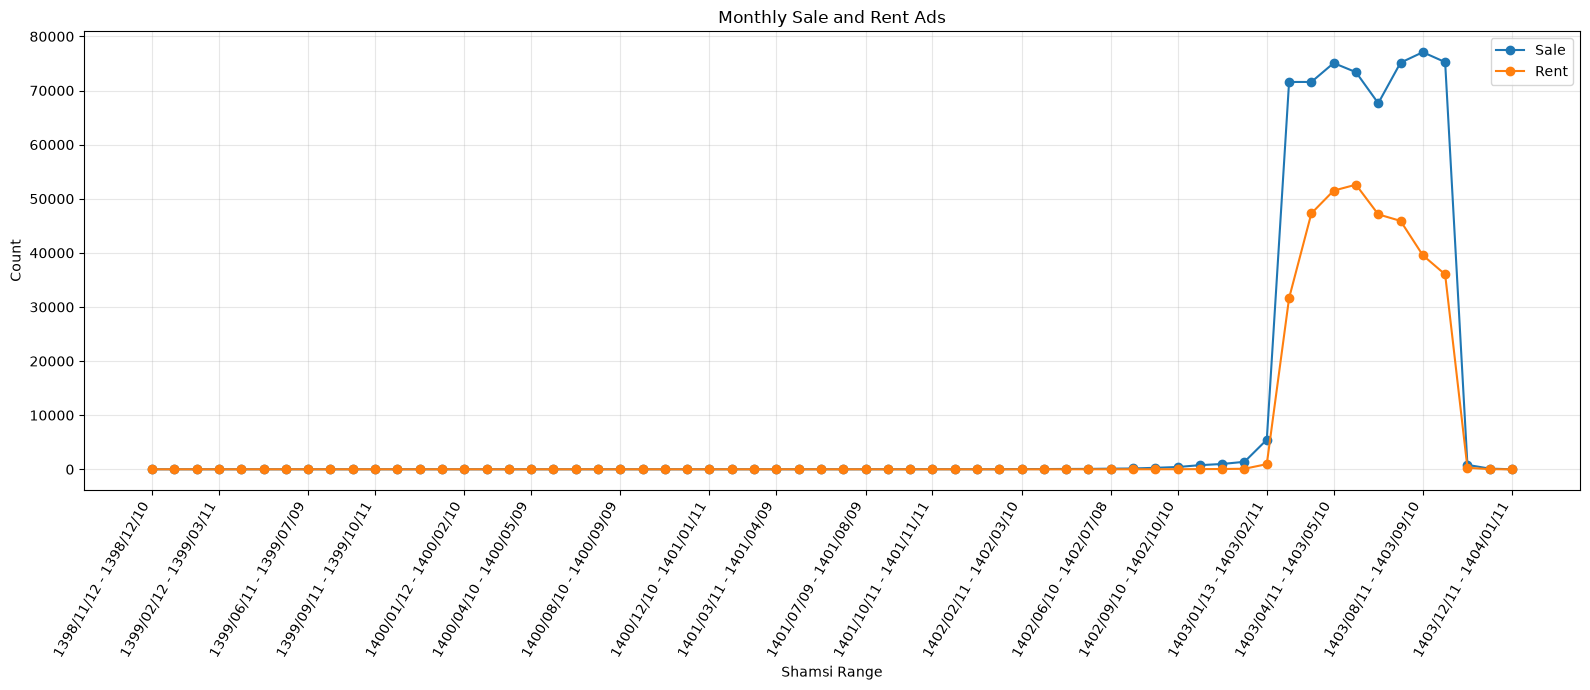

In [8]:
fig, ax = plt.subplots(figsize=(16, 7))

for ad_type in ["Sale", "Rent"]:
    ax.plot(
        range(len(monthly_count)), monthly_count[ad_type],
        marker="o", label=ad_type
    )

ax.set_xticks(tick_positions)
ax.set_xticklabels(count_summary.index[tick_positions], rotation=60, ha="right")
ax.set(title="Monthly Sale and Rent Ads", xlabel="Shamsi Range", ylabel="Count")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# peak months and increases
monthly_change = monthly_count.pct_change(fill_method=None) * 100
monthly_change = monthly_change.replace([np.inf, -np.inf], np.nan)

month_numbers = pd.Series([
    month.year * 12 + month.month for month in monthly_count.index
], index=monthly_count.index)
monthly_change.loc[month_numbers.diff().ne(1)] = np.nan

for ad_type in ["Sale", "Rent"]:
    counts = monthly_count[ad_type]
    if counts.empty or counts.sum() == 0:
        print(f"{ad_type}: no ads")
        continue

    peak_months = counts[counts == counts.max()].index
    print(f"{ad_type} - peak range(s):", [month_labels[m] for m in peak_months])
    print(f"Count: {counts.max():,}")

    increases = monthly_change[ad_type].dropna()
    increases = increases[increases > 0]
    if not increases.empty:
        increase_month = increases.idxmax()
        previous_month = increase_month - 1
        print(f"Largest monthly increase: {month_labels[increase_month]}")
        print(f"{counts.loc[previous_month]:,} -> {counts.loc[increase_month]:,}")
        print(f"Increase: {increases.max():.2f}%")
    else:
        print("No positive change between consecutive observed months.")
    print()

Sale - peak range(s): ['1403/08/11 - 1403/09/10']
Count: 77,085
Largest monthly increase: 1403/02/12 - 1403/03/11
5,465 -> 71,581
Increase: 1209.81%

Rent - peak range(s): ['1403/05/11 - 1403/06/10']
Count: 52,599
Largest monthly increase: 1403/02/12 - 1403/03/11
952 -> 31,633
Increase: 3222.79%



خروجی، ماه‌های اوج و بزرگ‌ترین افزایش را نشان می‌دهد. درصد افزایش را کنار تعداد آگهی‌ها می‌خوانیم؛ افزایش از تعداد خیلی کم می‌تواند درصد بزرگی بسازد. نتیجه فقط دربارهٔ آگهی‌های همین دیتاست است و الگوی تکرارشوندهٔ سالانه را ثابت نمی‌کند.

### F :
task 2 : ترند میانگین قیمت اجاره بر حسب ماه.

در دیتاست اصلی، `transformable_price` بولی است و `transformed_credit` فقط برای بخشی از آگهی‌ها پر شده؛ این ستون‌ها قیمت مشترک همهٔ آگهی‌ها نیستند.

طبق تعریف سؤال، قیمت اجاره را **معادل رهن کامل** می‌گیریم. نسبت نمونهٔ سؤال را فرض می‌کنیم: هر یک میلیون رهن برابر سی هزار اجاره؛ پس `رهن معادل = رهن اصلی + اجارهٔ ماهانه / 0.03`.

In [10]:
# equivalent full deposit
rent_data = monthly_data[monthly_data["ad_type"].eq("Rent")].copy()
conversion_rate = 0.03

for column, mode in [("credit_value", "credit_mode"), ("rent_value", "rent_mode")]:
    rent_data[column] = pd.to_numeric(rent_data[column], errors="coerce")
    rent_data.loc[rent_data[mode].eq("مجانی"), column] = 0
    rent_data.loc[rent_data[mode].eq("توافقی"), column] = np.nan
    rent_data[column] = rent_data[column].replace([np.inf, -np.inf], np.nan)
    rent_data.loc[rent_data[column] < 0, column] = np.nan

rent_data["rental_price"] = (
    rent_data["credit_value"] + rent_data["rent_value"] / conversion_rate
).replace([np.inf, -np.inf], np.nan)

print("Rental ads:", len(rent_data))
print("Valid rental prices:", rent_data["rental_price"].count())
rent_data = rent_data.dropna(subset=["rental_price"])

Rental ads: 353125
Valid rental prices: 351181


In [11]:
#main task :
monthly_rent = (
    rent_data.groupby("month")["rental_price"]
    .agg(["count", "mean"])
    .reindex(month_order)
)
monthly_rent["count"] = monthly_rent["count"].fillna(0).astype(int)

rent_summary = monthly_rent.copy()
rent_summary.index = rent_summary.index.map(month_labels)
rent_summary.index.name = "Shamsi range"
rent_summary

,count,mean
Shamsi range,,
1398/11/12 - 1398/12/10,0,NaN
1398/12/11 - 1399/01/12,0,NaN
1399/01/13 - 1399/02/11,0,NaN
1399/02/12 - 1399/03/11,0,NaN
1399/03/12 - 1399/04/10,0,NaN
...,...,...
1403/08/11 - 1403/09/10,39531,1.567584e+12
1403/09/11 - 1403/10/11,36003,1.834766e+12
1403/10/12 - 1403/11/12,288,2.165430e+09


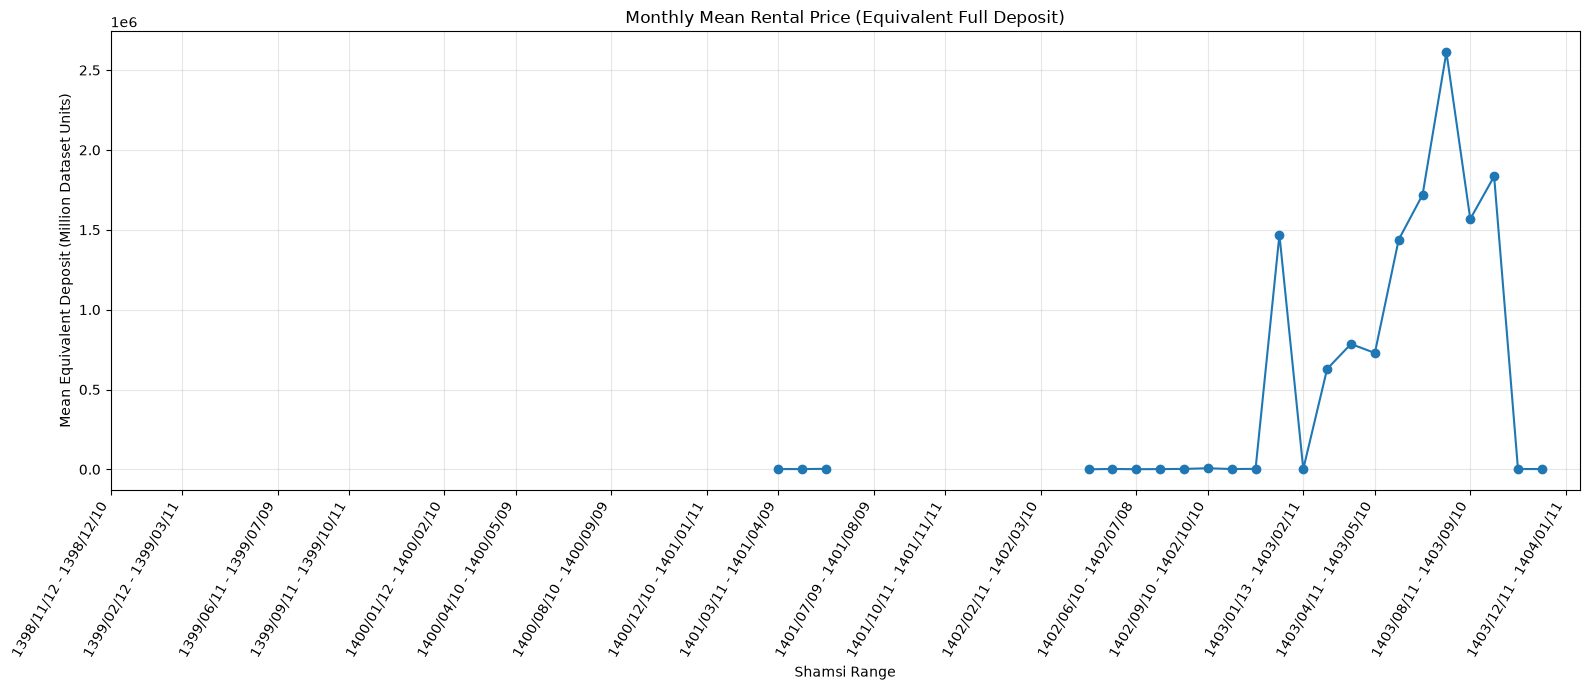

In [12]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(range(len(monthly_rent)), monthly_rent["mean"] / 1_000_000, marker="o")
ax.set_xticks(tick_positions)
ax.set_xticklabels(rent_summary.index[tick_positions], rotation=60, ha="right")
ax.set(
    title="Monthly Mean Rental Price (Equivalent Full Deposit)",
    xlabel="Shamsi Range",
    ylabel="Mean Equivalent Deposit (Million Dataset Units)"
)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

`count` تعداد قیمت‌های معتبر است؛ ماه بدون قیمت معتبر میانگین ندارد. قیمت توافقی و مقدار ناموجود را صفر فرض نمی‌کنیم. صفرِ واقعی و قیمت‌های بزرگ حفظ می‌شوند؛ بنابراین مقدارهای خیلی بزرگ روی میانگین اثر دارند. جدول در واحد اصلی فایل است و نمودار در میلیونِ همان واحد.

منبع ساختار داده: [Divar Real Estate Ads](https://huggingface.co/datasets/divarofficial/real_estate_ads).